In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import random

from sklearn.linear_model import LogisticRegression
from explainit import basic_function
from explainit.logging_config import logger

import numpy as np
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [4]:
# Example: Load German Credit dataset
df = pd.read_csv('data/german_credit_data.csv')  # Replace with your dataset path

# Improved preprocessing for your dataset

# Drop 'Unnamed: 0' as it's just an index
df = df.drop(columns=['Unnamed: 0'])

# Handle missing values in categorical columns by filling with 'missing'
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount','Duration']

df[cat_cols] = df[cat_cols].fillna('missing')

# Encode target: convert 'Risk' to binary (e.g., 'good' = 1, 'bad' = 0)
df['target'] = (df['Risk'] == 'good').astype(int)
df = df.drop(columns=['Risk'])

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Identify numerical and categorical columns
# num_cols = X.select_dtypes(include=np.number).columns
# cat_cols = X.select_dtypes(exclude=np.number).columns

# Scale numerical features
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X.index)
X = pd.concat([X[num_cols], X_cat], axis=1)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Preprocess: scale numerical, encode categorical
# num_cols = X.select_dtypes(include=np.number).columns
# cat_cols = X.select_dtypes(exclude=np.number).columns

scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X[num_cols], X_cat], axis=1)
for col in encoder.get_feature_names_out(encoder.feature_names_in_):
    X[col] = X[col].astype('category')
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (e.g., Random Forest)
# model = RandomForestClassifier()
# model.fit(X_train, y_train)

# Predict and check accuracy
# y_pred = model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))


# Train a classifier (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and check accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]


df_tot = X.copy()
y_tot = model.predict(df_tot)
df_tot['prediction'] = y_tot
idx = df_tot[df_tot.prediction == 0].sample().index[0]
sample = X.loc[idx, :]
data_np = X.values

Accuracy: 0.76


## 1. Wybieram próbkę której wynik chcę zmienić 

In [5]:
sample = [0.69642857, 0.86359635, 0.73529412, 
    0., 1.,
    0., 0., 1., 0.,
    0., 0., 1., 
    1., 0., 0., 0., 0.,
    0., 0., 1., 0.,
    1., 0., 0., 0., 0., 0., 0., 0.]

## 2. Wyznaczam wynik który chcę osiągnąć modelem

In [6]:
# target = [0.40, 0.60]
target = 0.60

## 3. Wyznaczam granice, bariery i wagi zmiennych sugerując co chciałbym i mogę zmienić żeby osiągnąć wynik z 2.

```
'column': index

'Age': 0
'Credit amount': 1
'Duration': 2
'Sex_female': 3
'Sex_male': 4
'Job_0': 5
'Job_1': 6
'Job_2': 7
'Job_3':8
'Housing_free': 9
'Housing_own': 10
'Housing_rent': 11
'Saving accounts_little': 12
'Saving accounts_missing': 13
'Saving accounts_moderate': 14
'Saving accounts_quite rich': 15
'Saving accounts_rich': 16
'Checking account_little': 17
'Checking account_missing': 18
'Checking account_moderate': 19
'Checking account_rich': 20
'Purpose_business': 21
'Purpose_car': 22
'Purpose_domestic appliances': 23
'Purpose_education': 24
'Purpose_furniture/equipment': 25
'Purpose_radio/TV': 26
'Purpose_repairs': 27
'Purpose_vacation/others': 28
```

In [ ]:
def exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5):
    """
    Exponential function from 0 to 1 (increasing) or 1 to 0 (decreasing).
    If increasing=True: 0 for x <= x0, 1 for x >= x1.
    If increasing=False: 1 for x <= x0, 0 for x >= x1.
    a : controls the steepness of the transition (the greater value of a increases steepness)
    Always returns a numpy array.
    """
    x = np.asarray(x)
    if x1 > x0:
        t = (x - x0) / (x1 - x0)
        t = np.clip(t, 0, 1)
        curve = (np.exp(a * t) - 1) / (np.exp(a) - 1)
        if increasing:
            val = np.where(x <= x0, 0.0, np.where(x >= x1, 1.0, curve))
        else:
            val = np.where(x <= x0, 1.0, np.where(x >= x1, 0.0, 1 - curve))
    else:
        val = np.zeros_like(x) if increasing else np.ones_like(x)
    return val

min_cread_am = 0.65
max_cread_am = X.iloc[1,:].max()
min_duration = 0.60
max_duration = X.iloc[2,:].max()
def cred_am_weight(x):
    return exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def duration_weight(x):
    return exp_increasing(x, x0=0.60, x1=0.73, increasing=True, a = 5)



# 4. I perform random search

In [8]:
# Inputs

# priorities
# sample
# target
model_pred = lambda x: model.predict_proba(x)[:,1] # selecting output interesting for me

In [56]:
priorities = {
    'numerical':{0: 0,
                1: {'function':cred_am_weight,'min':min_cread_am, 'max':max_cread_am},
                2: {'function':duration_weight,'min':min_duration, 'max':max_duration}
},
    'categorical':{
                (3,4): {(1.0, 0.0): 0,
                        (0.0, 1.0): 1},
                (5,6,7,8): {(1.0,0.0,0.0,0.0): 0,
                            (0.0,1.0,0.0,0.0): 0,
                            (0.0,0.0,1.0,0.0): 1,
                            (0.0,0.0,0.0,1.0): 1},
                (9,10,11): {(1.0, 0.0, 0.0): 1,
                            (0.0, 1.0, 0.0): 1,
                            (0.0, 0.0, 1.0): 1},
                (12,13,14,15,16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 0.0, 1.0, 0.0): 0,
                                    (0.0, 0.0, 0.0, 0.0, 1.0): 0},
                (17,18,19,20): {(1.0, 0.0, 0.0, 0.0): 1,
                                (0.0, 1.0, 0.0, 0.0): 1,
                                (0.0, 0.0, 1.0, 0.0): 1,
                                (0.0, 0.0, 0.0, 1.0): 0},
                (21,22,23,24,25,26,27,28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 1}
    }
}


def filter_priorities(sample, priorities):
    new_priorities = {'numerical': {}, 'categorical': {}}

    # Numerical: replace 0 with sample value
    for idx, val in priorities['numerical'].items():
        if val == 0:
            new_priorities['numerical'][idx] = sample[idx]
        else:
            new_priorities['numerical'][idx] = val

    # Categorical: remove elements with value 0
    for group, mapping in priorities['categorical'].items():
        filtered_mapping = {k: v for k, v in mapping.items() if v != 0}
        if filtered_mapping:
            new_priorities['categorical'][group] = filtered_mapping

    return new_priorities

def investigate_distribution(f, min, max, n_samples=10000):

    def calculate_empirical_distribution(n_samples=10000):
        accepted_values = []
        
        for _ in range(n_samples):
            val = sample_numeric_value({
                'function': f, 
                'min': min, 
                'max': max
            })
            accepted_values.append(val)
        
        return np.array(accepted_values)

    # Calculate theoretical distribution
    x_vals = np.linspace(min, max, 1000)
    weights = np.array([float(f(x)) for x in x_vals])

    # Normalize to get probability density
    prob_density = weights / np.trapezoid(weights, x_vals)

    # Generate samples
    samples = calculate_empirical_distribution(n_samples)

    # Calculate histogram (probability mass in bins)
    hist, bin_edges = np.histogram(samples, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    plt.plot(x_vals, prob_density)
    plt.xlabel('Credit Amount')
    plt.ylabel('Probability Density')
    plt.title('Theoretical Distribution')

    plt.bar(bin_centers, hist, width=np.diff(bin_edges), alpha=0.7)
    plt.xlabel('Credit Amount')
    plt.ylabel('Probability Density')
    plt.title('Empirical Distribution')

    plt.tight_layout()
    plt.show()


def sample_numeric_value(constraint, max_tries=100):
    """Uses Monte Carlo sampling to sample a numeric value based on a constraint function.
    - Rejection Sampling (your primary method)
    - Inverse Transform Sampling (your fallback, discretized)"""

    min_val = constraint['min']
    max_val = constraint['max']
    f = constraint['function']

    # Rejection sampling (works with any shape as long as 0 <= f(x) <= 1)
    for _ in range(max_tries):
        rv = np.random.uniform(min_val, max_val)
        w = float(np.asarray(f(rv)).squeeze())
        # w = np.clip(w, 0.0, 1.0)
        if np.random.random() < w:
            return rv

    # Fallback: sample proportional to f over a grid (shape-agnostic)
    xs = np.linspace(min_val, max_val, 256)
    ws = np.asarray(f(xs)).astype(float).ravel()
    ws = np.clip(ws, 0.0, None)
    if ws.sum() == 0 or not np.isfinite(ws).all():
        return np.random.uniform(min_val, max_val)
    p = ws / ws.sum()
    idx = np.random.choice(len(xs), p=p)
    jitter = (max_val - min_val) / 256 * (np.random.random() - 0.5)
    return float(np.clip(xs[idx] + jitter, min_val, max_val))


def generate_random_samples(priorities, sample, target, model_pred, n_samples=10, epsilon=0.05, random_seed=42, use_monte_carlo=True):
    """
    Generate random samples based on filtered priorities.
    Only keep samples whose prediction is within epsilon of the target.
    """
    filtered_priorities = filter_priorities(sample, priorities)
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    samples = []
    predictions = []
    n_features = 29
    
    for _ in range(n_samples):
        sample = np.zeros(n_features)
        # Numerical features
        for idx, constraint in filtered_priorities['numerical'].items():
            if isinstance(constraint, dict) and 'function' in constraint:
                sample[idx] = sample_numeric_value(constraint) if use_monte_carlo else np.random.uniform(constraint['min'], constraint['max'])
            else:
                sample[idx] = constraint

        # Categorical features: sample combos with probability proportional to their weights
        for group_indices, possible_values in filtered_priorities['categorical'].items():
            combos = list(possible_values.keys())
            weights = np.array(list(possible_values.values()), dtype=float)
            if weights.sum() > 0:
                weights = weights / weights.sum()
                sel = combos[np.random.choice(len(combos), p=weights)]
            else:
                sel = random.choice(combos)
            for i, idx in enumerate(group_indices):
                sample[idx] = sel[i]

        # Get prediction
        try:
            pred = model_pred(sample.reshape(1, -1))[0]
            if abs(pred - target) <= epsilon:
                samples.append(sample.copy())
                predictions.append(pred)
        except Exception as e:
            logger.warning(f"Could not get prediction for sample: {e}")
    return samples, predictions


samples, predictions = generate_random_samples(priorities, sample, target, model_pred, n_samples=10000, epsilon=0.05, use_monte_carlo=True)


In [61]:
def calculate_sample_weight(sample, priorities):
    """
    Calculate the total weight for a sample based on the priorities structure.
    
    Args:
        sample: numpy array or list representing a single sample
        priorities: dictionary with 'numerical' and 'categorical' keys
    
    Returns:
        float: sum of all weights for the sample
    """
    total_weight = 0.0
    sample = np.asarray(sample)
    
    # Handle numerical features
    for idx, constraint in priorities['numerical'].items():
        if constraint == 0:
            # Weight is 0, so add 0 to total
            total_weight += 0
        elif isinstance(constraint, dict) and 'function' in constraint:
            # Apply the weight function to the sample value
            value = sample[idx]
            weight = float(constraint['function'](value))
            total_weight += weight
        else:
            # Direct value (shouldn't happen in your case, but for completeness)
            total_weight += float(constraint)
    
    # Handle categorical features
    for group_indices, possible_values in priorities['categorical'].items():
        # Extract the one-hot encoded values for this group
        group_values = tuple(sample[list(group_indices)])
        
        # Find the weight for this combination
        if group_values in possible_values:
            weight = possible_values[group_values]
            total_weight += weight
        else:
            # If combination not found, add 0 (or could raise an error)
            total_weight += 0
    
    return total_weight

def round_samples(samples, rounding_config=None):
    """
    Round numerical values in samples and remove duplicates.
    
    Args:
        samples: list of samples (each sample is a numpy array or list)
        rounding_config: dict mapping feature indices to decimal places
                        e.g., {0: 2, 1: 3, 2: 1} means round feature 0 to 2 decimals, etc.
                        If None, no rounding is applied.
    
    Returns:
        list: unique samples after rounding
    """
    if not samples or rounding_config is None:
        return samples
    
    rounded_samples = []
    
    for sample in samples:
        sample_array = np.asarray(sample).copy()
        
        # Apply rounding to specified features
        for feature_idx, decimal_places in rounding_config.items():
            if feature_idx < len(sample_array):
                sample_array[feature_idx] = np.round(sample_array[feature_idx], decimal_places)
        
        rounded_samples.append(sample_array)
    
    # Remove duplicates by converting to tuples (hashable) and back
    unique_tuples = set()
    unique_samples = []
    
    for sample in rounded_samples:
        sample_tuple = tuple(sample)
        if sample_tuple not in unique_tuples:
            unique_tuples.add(sample_tuple)
            unique_samples.append(sample)
    
    return unique_samples

def find_highest_weight_samples(samples, priorities, rounding_config=None):
    """
    Find the sample(s) with the highest weight. If multiple samples have the same highest weight,
    apply rounding and deduplication only to those samples.
    
    Args:
        samples: list of samples (each sample is a numpy array or list)
        priorities: dictionary with 'numerical' and 'categorical' keys
        rounding_config: dict mapping feature indices to decimal places for rounding
                        Only applied if there are multiple samples with the same highest weight
    
    Returns:
        tuple: (highest_weight_samples, highest_weight)
            - highest_weight_samples: list of samples with the highest weight (after optional rounding/dedup)
            - highest_weight: the highest weight value achieved
    """
    if not samples:
        return [], 0.0
    
    # Calculate weights for all samples
    weights = []
    for sample in samples:
        weight = calculate_sample_weight(sample, priorities)
        weights.append(weight)
    
    weights = np.array(weights)
    max_weight = np.max(weights)
    
    # Find all samples with the maximum weight
    max_indices = np.where(weights == max_weight)[0]
    highest_weight_samples = [samples[i] for i in max_indices]
    
    # Only apply rounding and deduplication if there are multiple samples with highest weight
    if len(highest_weight_samples) > 1 and rounding_config is not None:
        highest_weight_samples = round_samples(highest_weight_samples, rounding_config)
    
    return highest_weight_samples, max_weight
# Example usage with rounding configuration
rounding_config = {
    0: 2,  # Round Age (index 0) to 2 decimal places
    1: 2,  # Round Credit amount (index 1) to 2 decimal places  
    2: 2   # Round Duration (index 2) to 2 decimal place
}

# Use with your generated samples
if samples:  # if you have generated samples
    best_samples, best_weight = find_highest_weight_samples(
        samples, priorities, rounding_config
    )
    
    print(f"Highest weight achieved: {best_weight:.4f}")
    print(f"Number of samples with highest weight: {len(best_samples)}")
    
    if len(best_samples) == 1:
        print("\nSample with highest weight:")
        print(best_samples[0])
    else:
        print(f"\nSamples with highest weight (after rounding and deduplication):")
        for i, sample in enumerate(best_samples):
            print(f"Sample {i+1}: {sample}")
        
else:
    print("No samples generated yet.")



Highest weight achieved: 8.0000
Number of samples with highest weight: 782

Samples with highest weight (after rounding and deduplication):
Sample 1: [0.7  0.97 0.99 0.   1.   0.   0.   0.   1.   1.   0.   0.   0.   0.
 1.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   1.   0.
 0.  ]
Sample 2: [0.7  0.96 0.75 0.   1.   0.   0.   1.   0.   0.   1.   0.   0.   1.
 0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.
 0.  ]
Sample 3: [0.7  0.91 0.75 0.   1.   0.   0.   0.   1.   1.   0.   0.   0.   0.
 1.   0.   0.   0.   1.   0.   0.   0.   0.   1.   0.   0.   0.   0.
 0.  ]
Sample 4: [0.7  0.91 0.8  0.   1.   0.   0.   1.   0.   0.   1.   0.   0.   1.
 0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.
 0.  ]
Sample 5: [0.7  0.95 0.96 0.   1.   0.   0.   1.   0.   1.   0.   0.   0.   1.
 0.   0.   0.   0.   1.   0.   0.   0.   0.   1.   0.   0.   0.   0.
 0.  ]
Sample 6: [0.7  1.   0.75 0.   1.   0.   0.   0.   1.   0.   0.   1.   1.   0.
 0.   

/var/folders/r0/18mc62gx7gd4f4f2t45c76cr0000gn/T/ipykernel_5190/3529021889.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  prob_density = weights / np.trapz(weights, x_vals)


Text(0.5, 1.0, 'Theoretical Distribution')

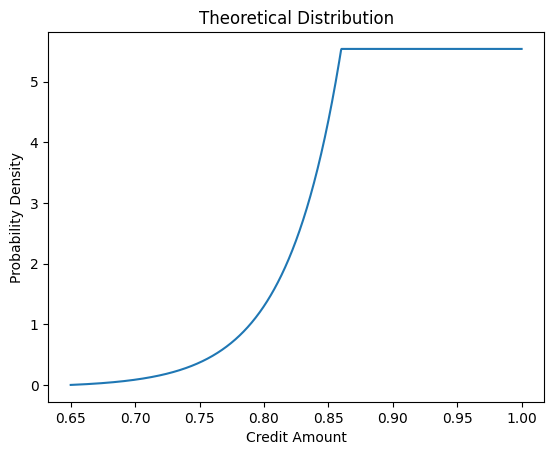

In [59]:
def investigate_distribution(f, min, max):

    def calculate_empirical_distribution(n_samples=10000):
        accepted_values = []
        
        for _ in range(n_samples):
            val = sample_numeric_value({
                'function': f, 
                'min': min, 
                'max': max
            })
            accepted_values.append(val)
        
        return np.array(accepted_values)

    # Calculate theoretical distribution
    x_vals = np.linspace(0.65, 1.0, 1000)
    weights = np.array([float(f(x)) for x in x_vals])

    # Normalize to get probability density
    prob_density = weights / np.trapz(weights, x_vals)

    plt.plot(x_vals, prob_density)
    plt.xlabel('Credit Amount')
    plt.ylabel('Probability Density')
    plt.title('Theoretical Distribution')



    # Generate samples
    samples = calculate_empirical_distribution(10000)

    # Calculate histogram (probability mass in bins)
    hist, bin_edges = np.histogram(samples, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    plt.bar(bin_centers, hist, width=np.diff(bin_edges), alpha=0.7)
    plt.xlabel('Credit Amount')
    plt.ylabel('Probability Density')
    plt.title('Empirical Distribution')

def cred_am_weight(x):
    return exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a=5)

investigate_distribution(cred_am_weight, min=0.65, max=0.1)

IndentationError: unexpected indent (1855423935.py, line 1)

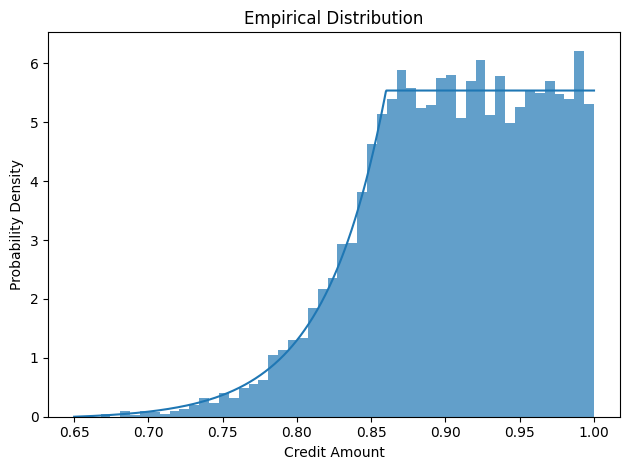

In [33]:
import numpy as np
import matplotlib.pyplot as plt



def cred_am_weight(x):
    return exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a=5)

min = 0.65
max = 1.0
investigate_distribution(cred_am_weight, min, max)

